<a href="https://colab.research.google.com/github/siranjithsiran/AGRICULTURAL-EDA/blob/main/AGRICULTURAL_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install plotly

/tmp/ipython-input-563393667.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rice_states.values, y=top_rice_states.index, palette="YlGnBu")


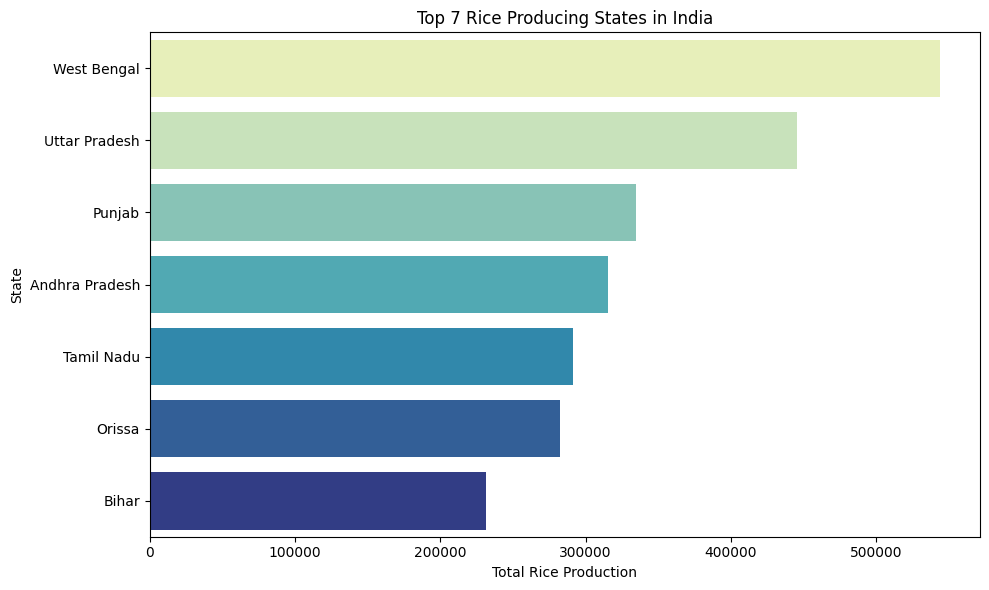

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px




data = pd.read_csv("/content/indian agricultural data.csv")


top_rice_states = data.groupby('State Name')['RICE PRODUCTION (1000 tons)'].sum().sort_values(ascending=False).head(7)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_rice_states.values, y=top_rice_states.index, palette="YlGnBu")
plt.title('Top 7 Rice Producing States in India')
plt.xlabel('Total Rice Production')
plt.ylabel('State')
plt.tight_layout()
plt.show()

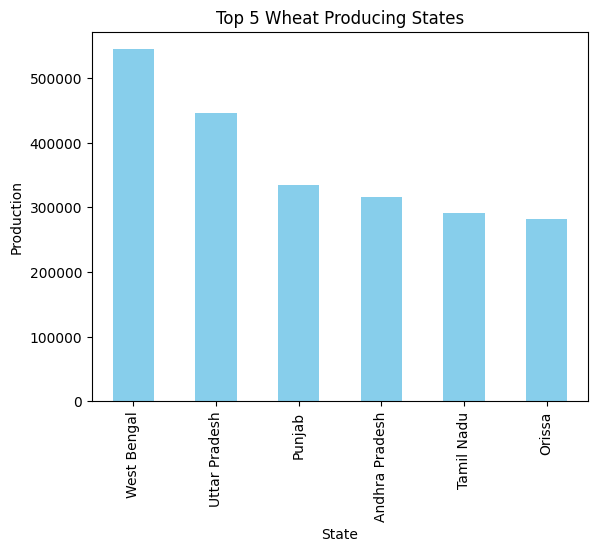

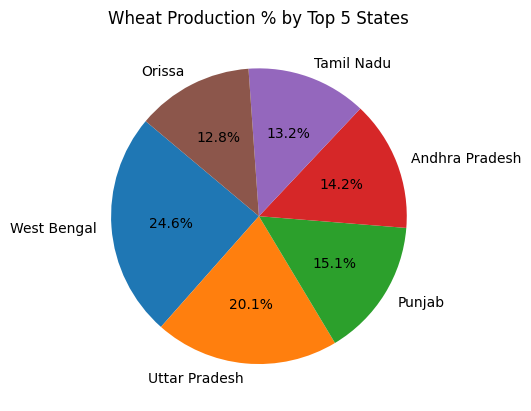

In [9]:
top_wheat = data.groupby('State Name')['RICE PRODUCTION (1000 tons)'].sum().sort_values(ascending=False).head(6)

top_wheat.plot(kind='bar', color='skyblue')
plt.title("Top 5 Wheat Producing States")
plt.ylabel("Production")
plt.xlabel("State")
plt.show()

top_wheat.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Wheat Production % by Top 5 States")
plt.ylabel("")  # Hide y-axis label
plt.show()

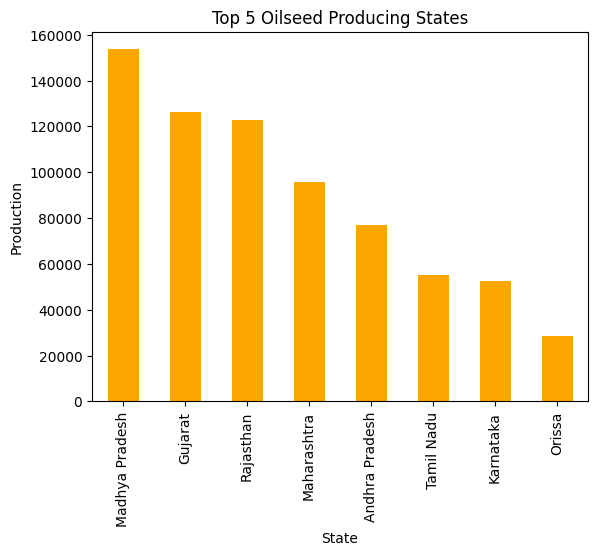

In [11]:
top_oilseeds = data.groupby('State Name')['OILSEEDS PRODUCTION (1000 tons)'].sum().sort_values(ascending=False).head(8)

top_oilseeds.plot(kind='bar', color='orange')
plt.title("Top 5 Oilseed Producing States")
plt.xlabel("State")
plt.ylabel("Production")
plt.show()

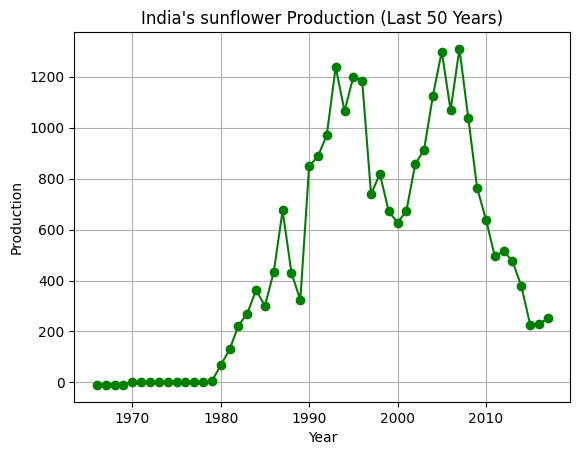

In [14]:
sugarcane_by_year = data.groupby('Year')['SUNFLOWER PRODUCTION (1000 tons)'].sum()

sugarcane_by_year.plot(kind='line', marker='o', color='green')
plt.title("India's sunflower Production (Last 50 Years)")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

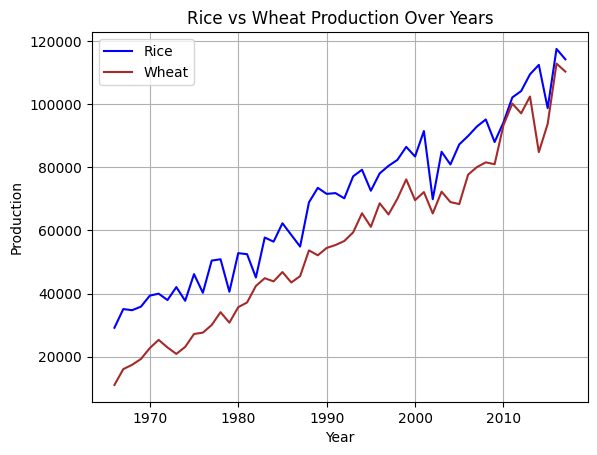

In [15]:
rice = data.groupby('Year')['RICE PRODUCTION (1000 tons)'].sum()
wheat = data.groupby('Year')['WHEAT PRODUCTION (1000 tons)'].sum()

plt.plot(rice.index, rice.values, label='Rice', color='blue')
plt.plot(wheat.index, wheat.values, label='Wheat', color='brown')
plt.title("Rice vs Wheat Production Over Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

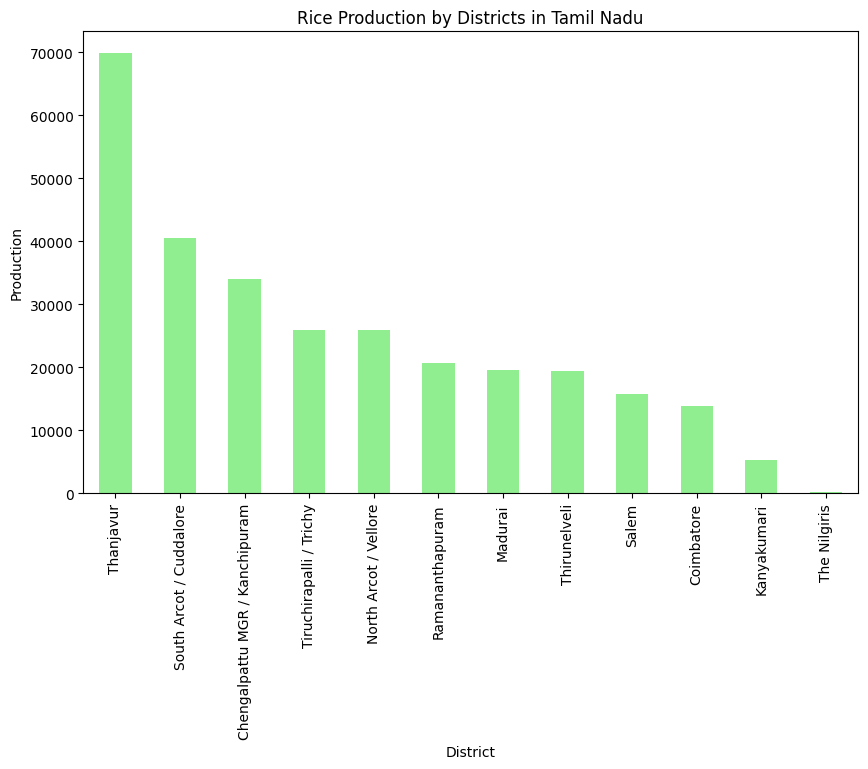

In [17]:
wb_rice = data[data['State Name'] == 'Tamil Nadu'].groupby('Dist Name')['RICE PRODUCTION (1000 tons)'].sum().sort_values(ascending=False)

wb_rice.plot(kind='bar', figsize=(10, 6), color='lightgreen')
plt.title("Rice Production by Districts in Tamil Nadu")
plt.xlabel("District")
plt.ylabel("Production")
plt.xticks(rotation=90)
plt.show()

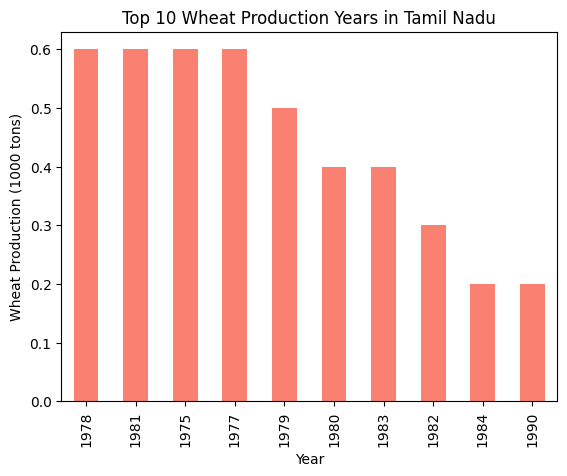

In [20]:
up_wheat = data[data['State Name'] == 'Tamil Nadu'].groupby('Year')['WHEAT PRODUCTION (1000 tons)'].sum().sort_values(ascending=False).head(10)

up_wheat.plot(kind='bar', color='salmon')
plt.title("Top 10 Wheat Production Years in Tamil Nadu")
plt.xlabel("Year")
plt.ylabel("Wheat Production (1000 tons)")
plt.show()

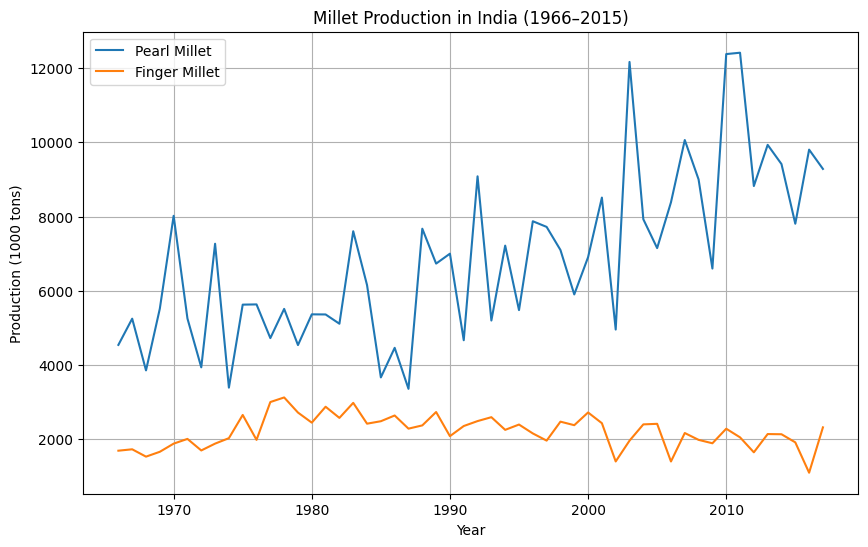

In [21]:
millet_cols = ['Year', 'PEARL MILLET PRODUCTION (1000 tons)', 'FINGER MILLET PRODUCTION (1000 tons)']
millet_df = data[millet_cols].groupby('Year').sum().reset_index()

plt.figure(figsize=(10,6))
plt.plot(millet_df['Year'], millet_df['PEARL MILLET PRODUCTION (1000 tons)'], label='Pearl Millet')
plt.plot(millet_df['Year'], millet_df['FINGER MILLET PRODUCTION (1000 tons)'], label='Finger Millet')
plt.title("Millet Production in India (1966–2015)")
plt.xlabel("Year")
plt.ylabel("Production (1000 tons)")
plt.legend()
plt.grid()
plt.show()

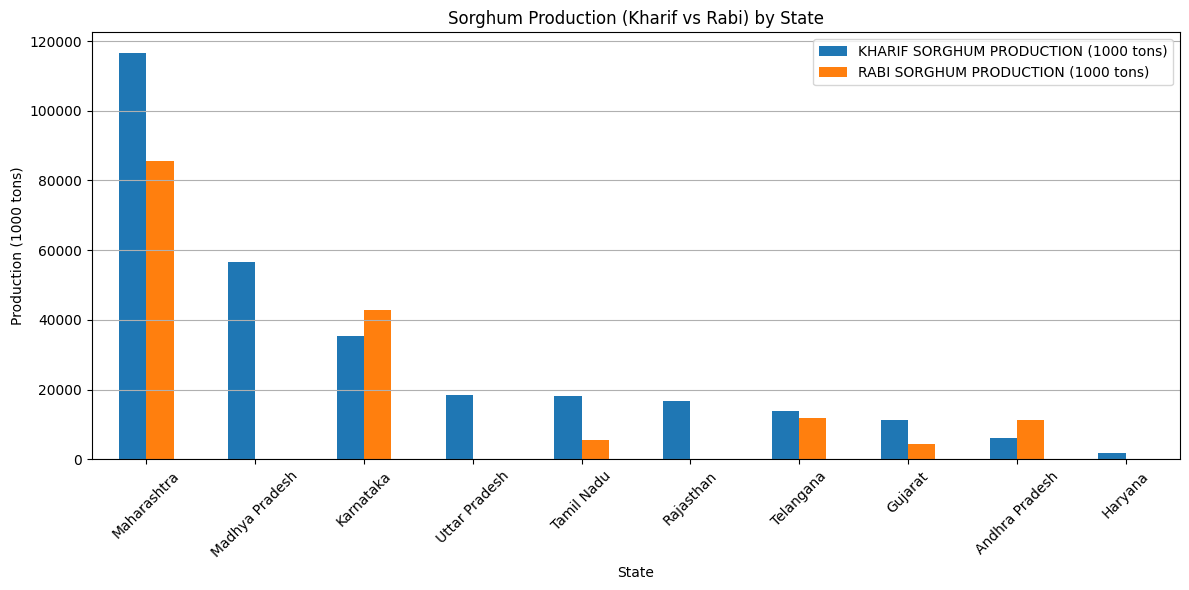

In [22]:
sorghum_season = data.groupby('State Name')[['KHARIF SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM PRODUCTION (1000 tons)']].sum().sort_values(by='KHARIF SORGHUM PRODUCTION (1000 tons)', ascending=False).head(10)

sorghum_season.plot(kind='bar', figsize=(12, 6))
plt.title("Sorghum Production (Kharif vs Rabi) by State")
plt.ylabel("Production (1000 tons)")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

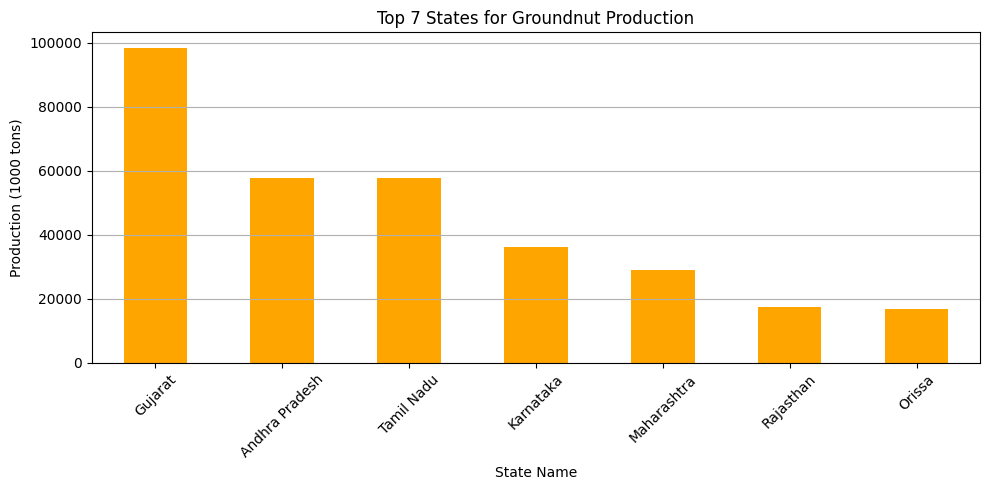

In [23]:
groundnut = data.groupby('State Name')['GROUNDNUT PRODUCTION (1000 tons)'].sum().sort_values(ascending=False).head(7)

groundnut.plot(kind='bar', color='orange', figsize=(10, 5))
plt.title("Top 7 States for Groundnut Production")
plt.ylabel("Production (1000 tons)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

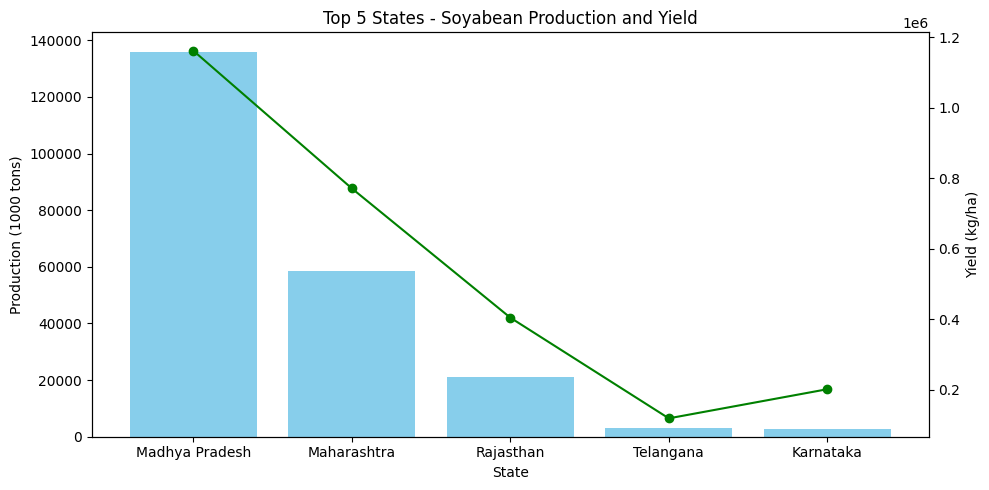

In [24]:
soybean = data.groupby('State Name')[['SOYABEAN PRODUCTION (1000 tons)', 'SOYABEAN YIELD (Kg per ha)']].sum().sort_values(by='SOYABEAN PRODUCTION (1000 tons)', ascending=False).head(5)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(soybean.index, soybean['SOYABEAN PRODUCTION (1000 tons)'], color='skyblue', label='Production')
ax1.set_ylabel("Production (1000 tons)")
ax1.set_xlabel("State")

ax2 = ax1.twinx()
ax2.plot(soybean.index, soybean['SOYABEAN YIELD (Kg per ha)'], color='green', marker='o', label='Yield Efficiency')
ax2.set_ylabel("Yield (kg/ha)")

plt.title("Top 5 States - Soyabean Production and Yield")
plt.tight_layout()
plt.show()

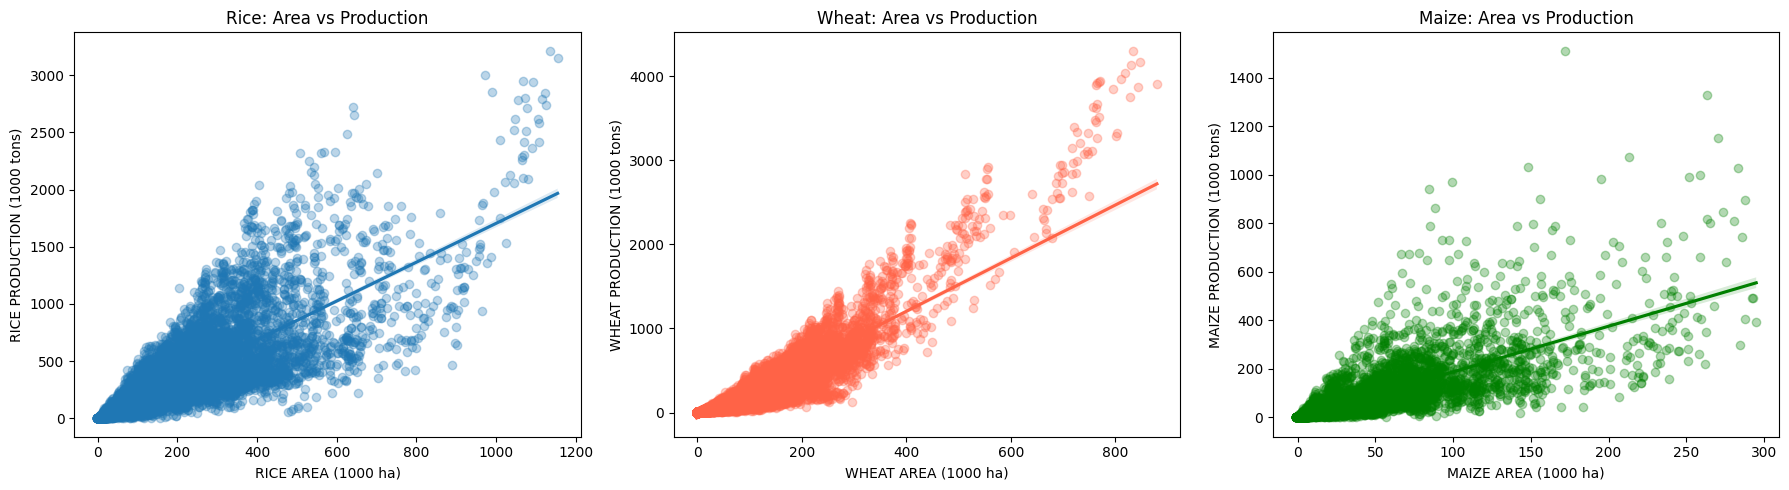

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='RICE AREA (1000 ha)', y='RICE PRODUCTION (1000 tons)', data=data, ax=axes[0], scatter_kws={'alpha':0.3})
axes[0].set_title("Rice: Area vs Production")

sns.regplot(x='WHEAT AREA (1000 ha)', y='WHEAT PRODUCTION (1000 tons)', data=data, ax=axes[1], scatter_kws={'alpha':0.3}, color='tomato')
axes[1].set_title("Wheat: Area vs Production")

sns.regplot(x='MAIZE AREA (1000 ha)', y='MAIZE PRODUCTION (1000 tons)', data=data, ax=axes[2], scatter_kws={'alpha':0.3}, color='green')
axes[2].set_title("Maize: Area vs Production")

plt.tight_layout()
plt.show()

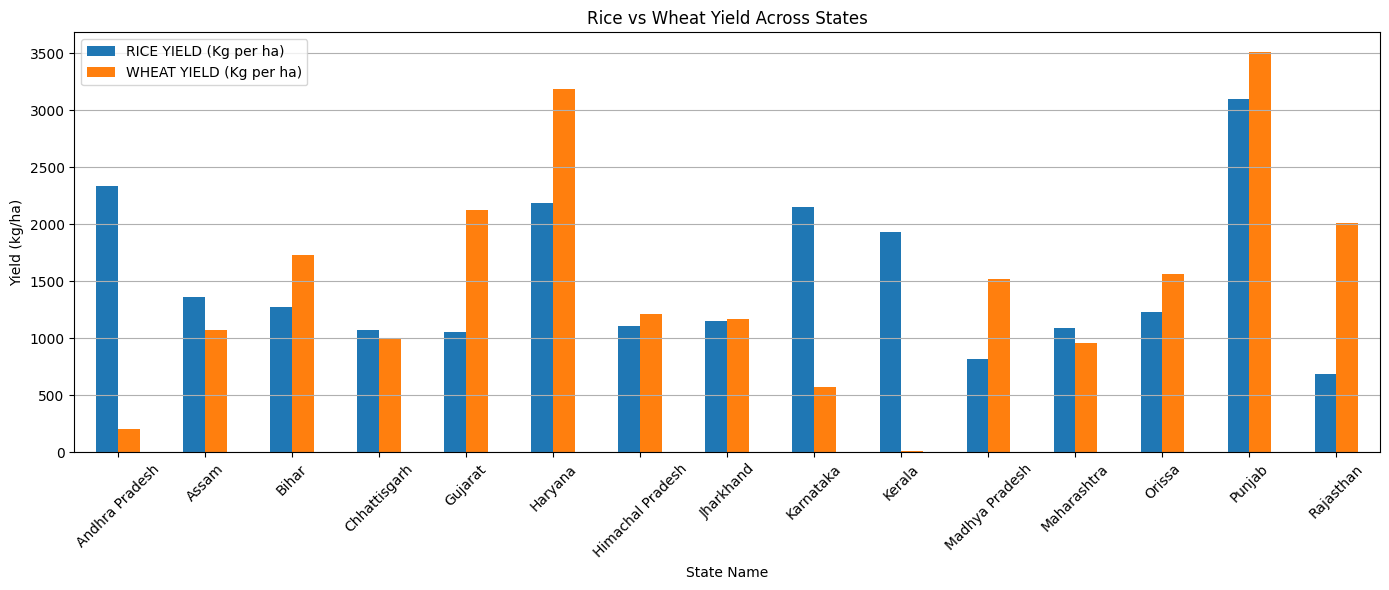

In [27]:
yield_data = data.groupby('State Name')[['RICE YIELD (Kg per ha)', 'WHEAT YIELD (Kg per ha)']].mean().dropna().head(15)

yield_data.plot(kind='bar', figsize=(14, 6))
plt.title("Rice vs Wheat Yield Across States")
plt.ylabel("Yield (kg/ha)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()